In [1]:
import torch
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns

from pyro_cases.run import vae_dict

In [2]:
pipeline_dict = {
    "amortized ELBO": "/data/scratch/pduan/gcvi_05-28_great_lake_output_test_summary.pt",
    "non-amortized ELBO": "/data/scratch/pduan/new_gcvi_output/gcvi_07-11_non_amortized_vae_larger_init_range_test_summary.pt",
    "set transformer FAVI": "/data/scratch/pduan/new_gcvi_output/gcvi_06-30_set_transformer_favi_test_summary.pt",
    "deep set FAVI": "/data/scratch/pduan/new_gcvi_output/gcvi_07-19_deep_set_favi_test_summary.pt",
}

In [3]:
pipeline_dict = {
    k: torch.load(v, map_location="cpu")
    for k, v in pipeline_dict.items()
}

In [4]:
all_p_combine = combinations(list(pipeline_dict.keys()), 2)
print_cases = False
for p1, p2 in all_p_combine:
    p1_data = pipeline_dict[p1]
    p2_data = pipeline_dict[p2]
    p1_tasks = set(p1_data.keys())
    p2_tasks = set(p2_data.keys())
    print("+" * 100)
    print(f"pipeline 1: {p1} (# tasks: {len(p1_tasks)})")
    print(f"pipeline 2: {p2} (# tasks: {len(p2_tasks)})")
    print(f"in p1, not in p2: {len(p1_tasks - p2_tasks)}")
    print(f"in p2, not in p1: {len(p2_tasks - p1_tasks)}")
    common_t = p1_tasks & p2_tasks
    print(f"common tasks: {len(common_t)}")
    metric_dict = {m: {"mean_p1_g_p2": [], "mean_p1_l_p2": [], "median_p1_g_p2": [], "median_p1_l_p2": []} for m in p1_data[list(common_t)[0]].keys()}
    for t in common_t:
        p1_t_metric = p1_data[t]
        p2_t_metric = p2_data[t]
        for mk, mv in p1_t_metric.items():
            if mv[0] > p2_t_metric[mk][0]:
                metric_dict[mk]["mean_p1_g_p2"].append(t)
            else:
                metric_dict[mk]["mean_p1_l_p2"].append(t)
            if mv[1] > p2_t_metric[mk][1]:
                metric_dict[mk]["median_p1_g_p2"].append(t)
            else:
                metric_dict[mk]["median_p1_l_p2"].append(t)
    for mdk, mdv in metric_dict.items():
        mean_1g2 = len(mdv["mean_p1_g_p2"])
        mean_1g2_cases = mdv["mean_p1_g_p2"]
        mean_1l2 = len(mdv["mean_p1_l_p2"])
        mean_1l2_cases = mdv["mean_p1_l_p2"]
        median_1g2 = len(mdv["median_p1_g_p2"])
        median_1g2_cases = mdv["median_p1_g_p2"]
        median_1l2 = len(mdv["median_p1_l_p2"])
        median_1l2_cases = mdv["median_p1_l_p2"]
        print(f"[metric mean {mdk}] ({p1}) > ({p2}): {mean_1g2}/{len(common_t)} ({mean_1g2 / len(common_t):.3f})")
        if print_cases:
            print(f"[metric mean {mdk}] ({p1}) > ({p2}): {mean_1g2_cases}")
        print(f"[metric mean {mdk}] ({p1}) <= ({p2}): {mean_1l2}/{len(common_t)} ({mean_1l2 / len(common_t):.3f})")
        if print_cases:
            print(f"[metric mean {mdk}] ({p1}) <= ({p2}): {mean_1l2_cases}")
        print(f"[metric median {mdk}] ({p1}) > ({p2}): {median_1g2}/{len(common_t)} ({median_1g2 / len(common_t):.3f})")
        if print_cases:
            print(f"[metric median {mdk}] ({p1}) > ({p2}): {median_1g2_cases}")
        print(f"[metric median {mdk}] ({p1}) <= ({p2}): {median_1l2}/{len(common_t)} ({median_1l2 / len(common_t):.3f})")
        if print_cases:
            print(f"[metric median {mdk}] ({p1}) <= ({p2}): {median_1l2_cases}")

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
pipeline 1: amortized ELBO (# tasks: 111)
pipeline 2: non-amortized ELBO (# tasks: 105)
in p1, not in p2: 7
in p2, not in p1: 1
common tasks: 104
[metric mean kl] (amortized ELBO) > (non-amortized ELBO): 60/104 (0.577)
[metric mean kl] (amortized ELBO) <= (non-amortized ELBO): 44/104 (0.423)
[metric median kl] (amortized ELBO) > (non-amortized ELBO): 52/104 (0.500)
[metric median kl] (amortized ELBO) <= (non-amortized ELBO): 52/104 (0.500)
[metric mean D] (amortized ELBO) > (non-amortized ELBO): 66/104 (0.635)
[metric mean D] (amortized ELBO) <= (non-amortized ELBO): 38/104 (0.365)
[metric median D] (amortized ELBO) > (non-amortized ELBO): 62/104 (0.596)
[metric median D] (amortized ELBO) <= (non-amortized ELBO): 42/104 (0.404)
[metric mean logp] (amortized ELBO) > (non-amortized ELBO): 33/104 (0.317)
[metric mean logp] (amortized ELBO) <= (non-amortized ELBO): 71/104 (0.683)
[metric me

In [5]:
all_tasks = list(vae_dict.keys())
pipeline_mean_D_dict = {k: [] for k in pipeline_dict.keys()}
pipeline_median_D_dict = {k: [] for k in pipeline_dict.keys()}
for k, v in pipeline_dict.items():
    for t in all_tasks:
        if t in v:
            pipeline_mean_D_dict[k].append(v[t]["D"][0])
            pipeline_median_D_dict[k].append(v[t]["D"][1])
        else:
            pipeline_mean_D_dict[k].append(-1)
            pipeline_median_D_dict[k].append(-1)
pipeline_mean_D_dict = {k: torch.tensor(v) for k, v in pipeline_mean_D_dict.items()}
pipeline_median_D_dict = {k: torch.tensor(v) for k, v in pipeline_median_D_dict.items()}

In [6]:
for i, t in enumerate(all_tasks):
    print(f"[{i + 1}] {t} D:")
    for k, v in pipeline_mean_D_dict.items():
        d_value = v[i]
        print(f"[{k}]: {d_value:.3e}; ", end="")
    print()
    print()

[1] gaussian_linear D:
[amortized ELBO]: 1.890e-02; [non-amortized ELBO]: 1.001e+00; [set transformer FAVI]: 2.465e-03; [deep set FAVI]: 2.959e-03; 

[2] gaussian_linear_uniform D:
[amortized ELBO]: 5.100e-02; [non-amortized ELBO]: 9.949e-01; [set transformer FAVI]: 3.179e-03; [deep set FAVI]: 3.501e-03; 

[3] slcp D:
[amortized ELBO]: 2.435e-01; [non-amortized ELBO]: -1.000e+00; [set transformer FAVI]: 1.932e-02; [deep set FAVI]: 1.311e-02; 

[4] slcp_distractors D:
[amortized ELBO]: 1.218e+00; [non-amortized ELBO]: -1.000e+00; [set transformer FAVI]: 7.356e-03; [deep set FAVI]: 5.914e-03; 

[5] bernoulli_glm_raw D:
[amortized ELBO]: 1.403e-01; [non-amortized ELBO]: -1.000e+00; [set transformer FAVI]: 5.797e-03; [deep set FAVI]: 3.207e-03; 

[6] bernoulli_glm D:
[amortized ELBO]: -1.000e+00; [non-amortized ELBO]: -1.000e+00; [set transformer FAVI]: 1.003e-01; [deep set FAVI]: 5.878e-02; 

[7] gaussian_mixture D:
[amortized ELBO]: 5.660e-02; [non-amortized ELBO]: 9.543e-01; [set transf

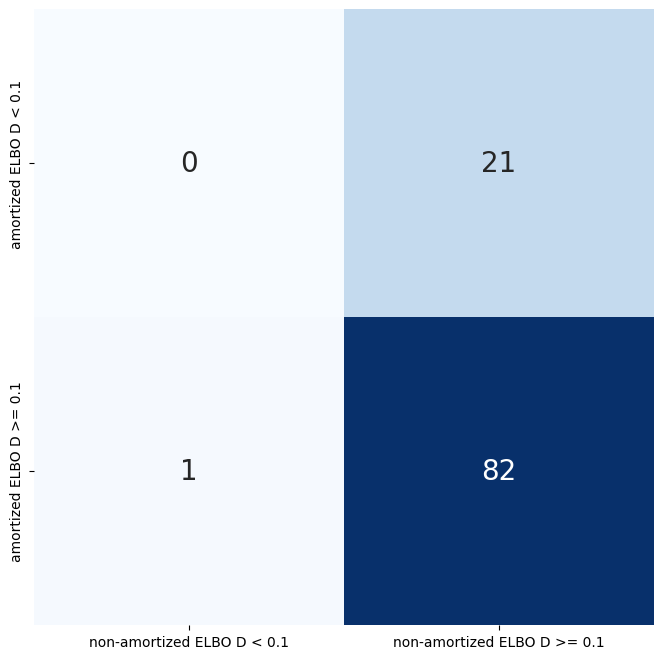

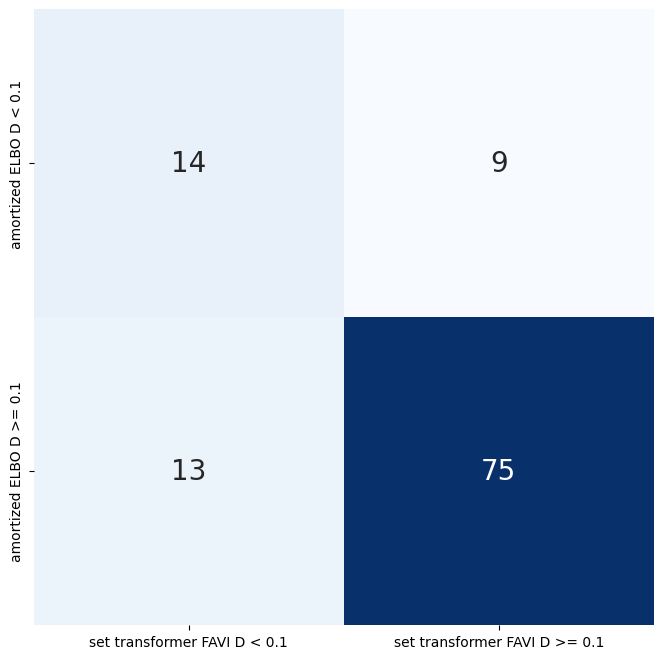

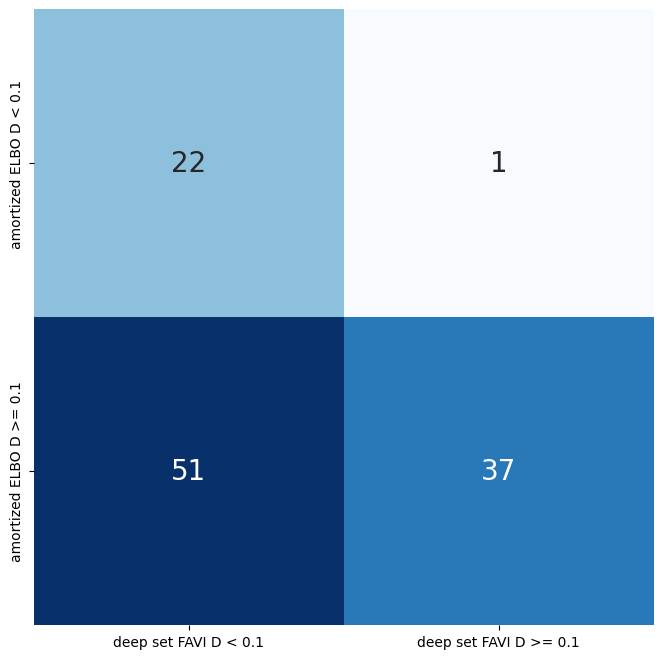

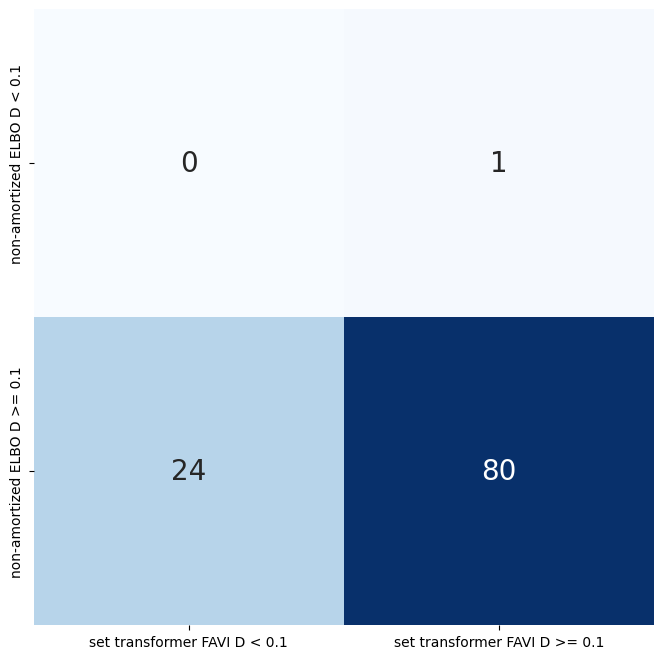

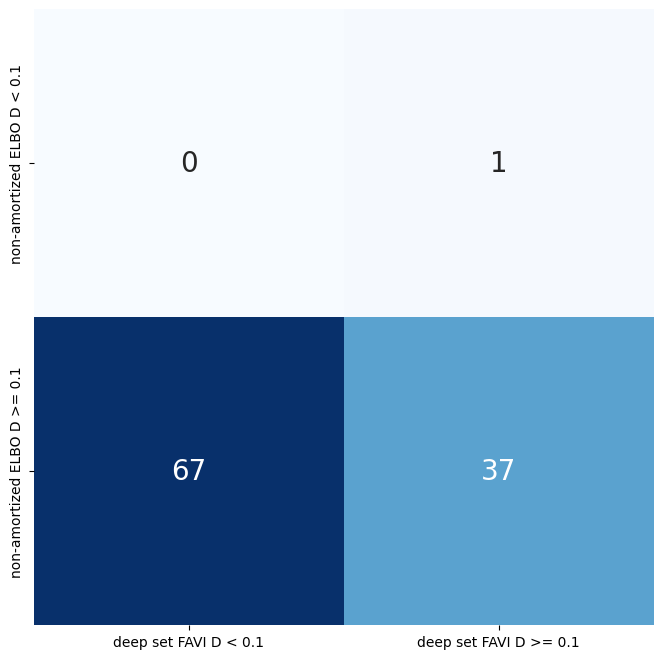

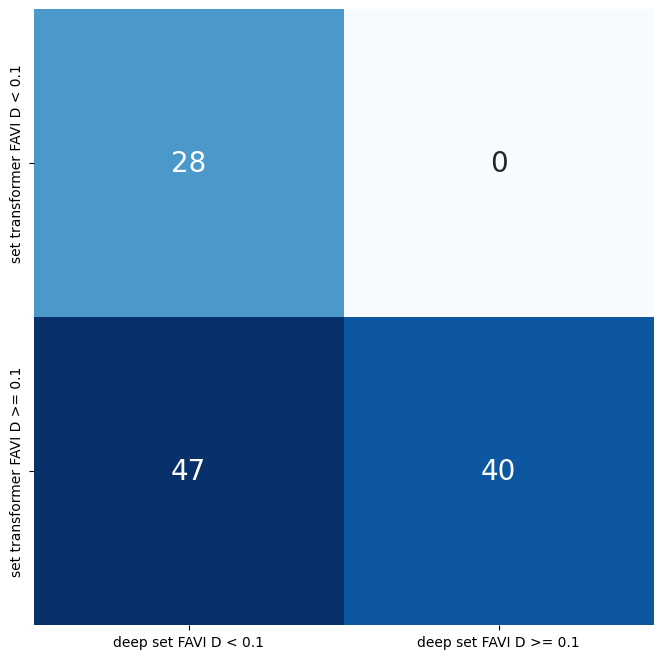

In [13]:
all_p_combine = combinations(list(pipeline_dict.keys()), 2)
D_boundary = 0.1
for p1, p2 in all_p_combine:
    p1_D = pipeline_mean_D_dict[p1]
    p2_D = pipeline_mean_D_dict[p2]
    mask = (p1_D > 0.0) & (p2_D > 0.0)
    p1_D = p1_D[mask]
    p2_D = p2_D[mask]
    D_b_matrix = torch.zeros(2, 2, dtype=torch.int)
    D_b_matrix[0, 0] = ((p1_D <= D_boundary) & (p2_D <= D_boundary)).sum()
    D_b_matrix[0, 1] = ((p1_D <= D_boundary) & (p2_D > D_boundary)).sum()
    D_b_matrix[1, 0] = ((p1_D > D_boundary) & (p2_D <= D_boundary)).sum()
    D_b_matrix[1, 1] = ((p1_D > D_boundary) & (p2_D > D_boundary)).sum()
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    sns.heatmap(D_b_matrix,
                annot=D_b_matrix,
                fmt="d",
                cbar=False,
                cmap="Blues",
                yticklabels=[f"{p1} D < {D_boundary:.1f}", f"{p1} D >= {D_boundary:.1f}"],
                xticklabels=[f"{p2} D < {D_boundary:.1f}", f"{p2} D >= {D_boundary:.1f}"],
                annot_kws={"fontsize": 20},
                ax=ax)
    fig.show()
    